# Scratchbook

In [1]:
import warnings

import matplotlib.pyplot as plt

import microbial_thermo as mt
from microbial_thermo.balance import infer_couples
from microbial_thermo.figures import plot_energy_explorer, plot_half_reactions, plot_redox_tower

# Nitrate to Hydroxylamine by H2 oxidation

In [2]:
EQUATION = "NO3- + H2 -> NH2OH"
conditions = mt.Conditions(temperature_c=25.0, pH=4)

> **A caution before anything else.** Hydroxylamine is in none of pyGCC's
> databases, so its formation energy comes from the hand-entered supplemental
> table and has **not** been traced to a primary source. Every number below
> inherits that uncertainty, and the library warns each time the value is
> used. Check it before relying on any of this.

In [3]:
from microbial_thermo.supplemental import supplemental_species

entry = supplemental_species()["NH2OH(aq)"]
print(f"NH2OH(aq)  dGf = {entry.delta_Gf_kJ_mol} kJ/mol at {entry.temperature_c} C")
print(f"verified: {entry.verified}")
print(entry.provenance.strip())

NH2OH(aq)  dGf = -23.5 kJ/mol at 25.0 C
verified: False
Commonly cited value for aqueous hydroxylamine; NOT yet traced to a primary source. Central nitrification intermediate, absent from every pyGCC database. CHECK BEFORE USE.


## 1. What the string implies

`infer_couples` reads the equation, finds which elements change oxidation
state, and forms the couples from that. Note that H₂'s partner — the proton —
never appears in the written equation; it is supplied.

In [4]:
donor, acceptor = infer_couples(EQUATION)
print("equation:", EQUATION)
print("donor    (reduced, oxidized):", donor)
print("acceptor (reduced, oxidized):", acceptor)

equation: NO3- + H2 -> NH2OH
donor    (reduced, oxidized): ('H2(aq)', 'H+')
acceptor (reduced, oxidized): ('NH2OH(aq)', 'NO3-')


Nitrogen goes from +5 in nitrate to −1 in hydroxylamine, so nitrate is the
acceptor. Hydrogen goes 0 → +1, so H₂ is the donor.

In [5]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    reaction = mt.Reaction.from_equation(EQUATION, conditions=conditions)

print(reaction.summary())

Reaction:  1/3 H+ + H2(aq) + 1/3 NO3- -> 1/3 NH2OH(aq) + 2/3 H2O
  donor     H+/H2(aq)  (oxidative)  E0' = -0.328 V
  acceptor  NO3-/NH2OH(aq)  (reductive)  E0' = +0.392 V
  n electrons        2
  dE0'               +0.721 V
  dG0'               -139.1 kJ/mol
  dG (conditions)    -139.1 kJ/mol
  dG per electron    -69.5 kJ/mol e-


## 2. The two half reactions

In [6]:
print("oxidation (donor):  ", reaction.donor_half.format())
print("reduction (acceptor):", reaction.acceptor_half.format())
print()
for label, result in (("donor", reaction.donor_half), ("acceptor", reaction.acceptor_half)):
    oxidized, reduced = result.oxidation_states()
    print(
        f"{label:9s} {result.couple}  "
        f"{result.half.key_element}: {oxidized} -> {reduced}   "
        f"E0' = {result.E_standard_prime.to('V').magnitude:+.3f} V"
    )

oxidation (donor):   H2(aq) -> 2 H+ + 2 e-
reduction (acceptor): 1/3 NO3- + 7/3 H+ + 2 e- -> 1/3 NH2OH(aq) + 2/3 H2O

donor     H+/H2(aq)  H: 1 -> 0   E0' = -0.328 V
acceptor  NO3-/NH2OH(aq)  N: 5 -> -1   E0' = +0.392 V


## 3. Normalised to one mole of the first reactant

The first reactant in the written equation is nitrate, so this is the
reaction per mole of nitrate reduced.

H+ + 3 H2(aq) + NO3- -> NH2OH(aq) + 2 H2O
n electrons = 6


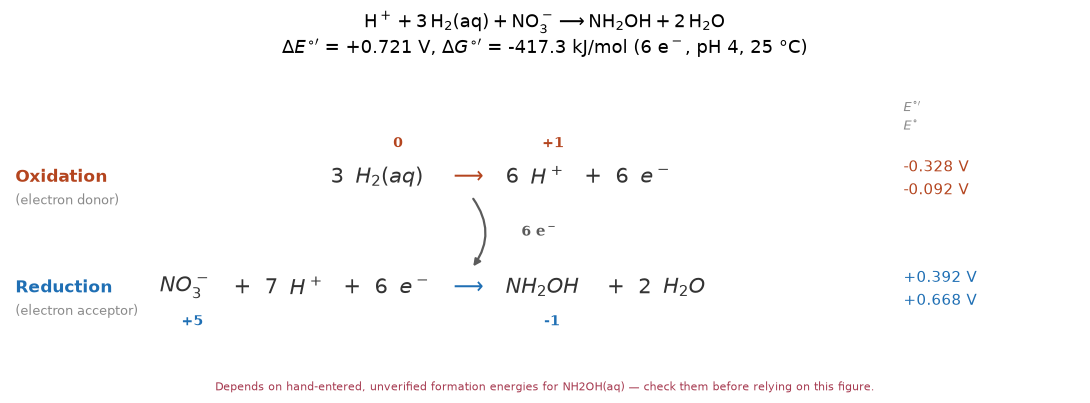

In [7]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    per_nitrate = mt.Reaction.from_equation(
        EQUATION, conditions=conditions, normalize_to="NO3-"
    )

print(per_nitrate.format())
print(f"n electrons = {per_nitrate.n_electrons}")
plot_half_reactions(per_nitrate, n_electrons=None)
plt.show()

## 4. Normalised to an electron pair

The same chemistry, scaled so exactly two electrons move. This is the
library's default for figures, and it is what makes couples comparable
against each other.

1/3 H+ + H2(aq) + 1/3 NO3- -> 1/3 NH2OH(aq) + 2/3 H2O


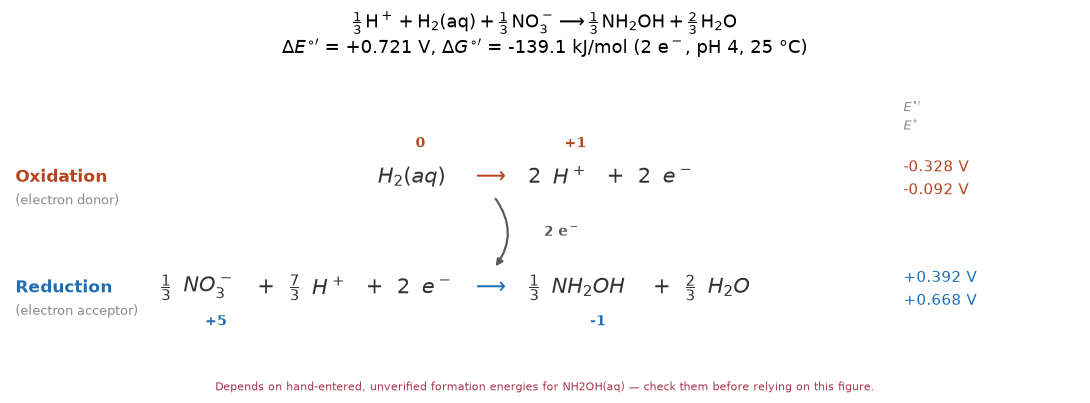

In [8]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    per_pair = per_nitrate.renormalized(2)

print(per_pair.format())
plot_half_reactions(per_pair)
plt.show()

A detail worth noticing before the tower: the donor here is `H2(aq)`, because
a bare `H2` resolves to dissolved hydrogen — the physiologically relevant
form. The tower's `2H+/H2` reference rung uses H₂ **gas**, so the donor marker
will not sit exactly on that rung:

In [9]:
from microbial_thermo.reaction import Couple, HalfReactionResult

for name in ("H2(aq)", "H2(g)"):
    pair = Couple.make(name, "H+")
    result = HalfReactionResult(
        couple=pair, half=pair.half_reaction(),
        conditions=conditions, backend=mt.get_backend(),
    )
    print(f"{name:8s} E0' = {result.E_standard_prime.to('V').magnitude:+.3f} V")

print("\nWrite H2(g) explicitly if you want the gas-phase convention.")

H2(aq)   E0' = -0.328 V
H2(g)    E0' = -0.237 V

Write H2(g) explicitly if you want the gas-phase convention.


## 5. The electron tower, both ways

The couple potentials are **intensive**: they do not change with
normalisation, so the rungs sit in exactly the same places on both towers.
What changes is the total free energy and therefore the energy scale bar,
which is drawn for the reaction's own electron count.

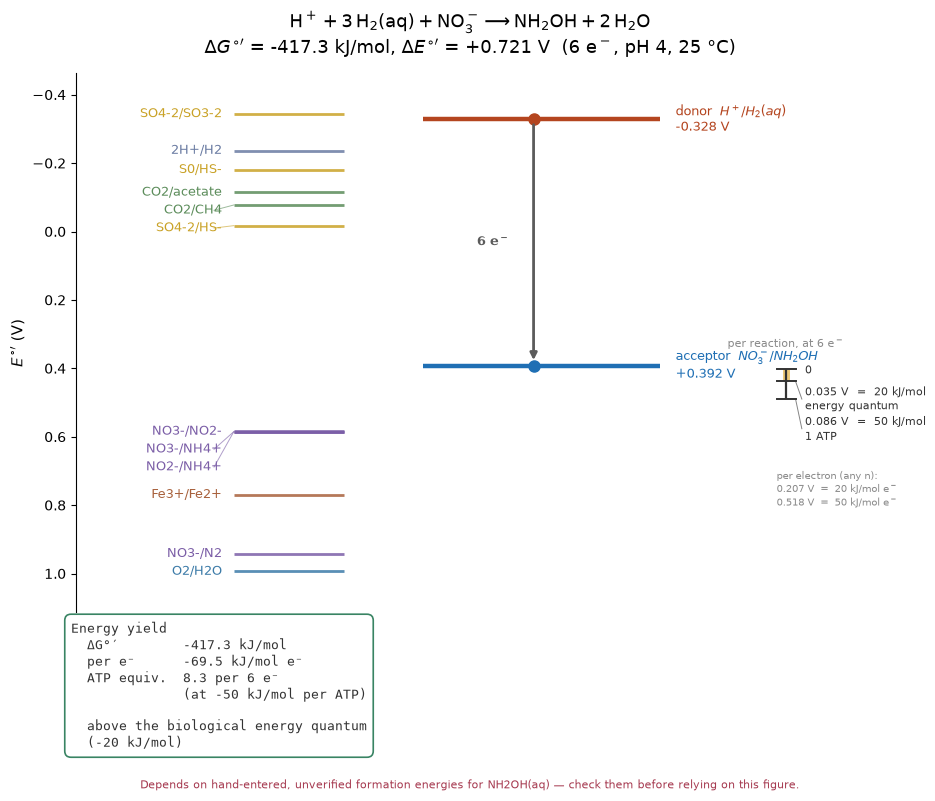

In [10]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    plot_redox_tower(per_nitrate, n_electrons=None)
plt.show()

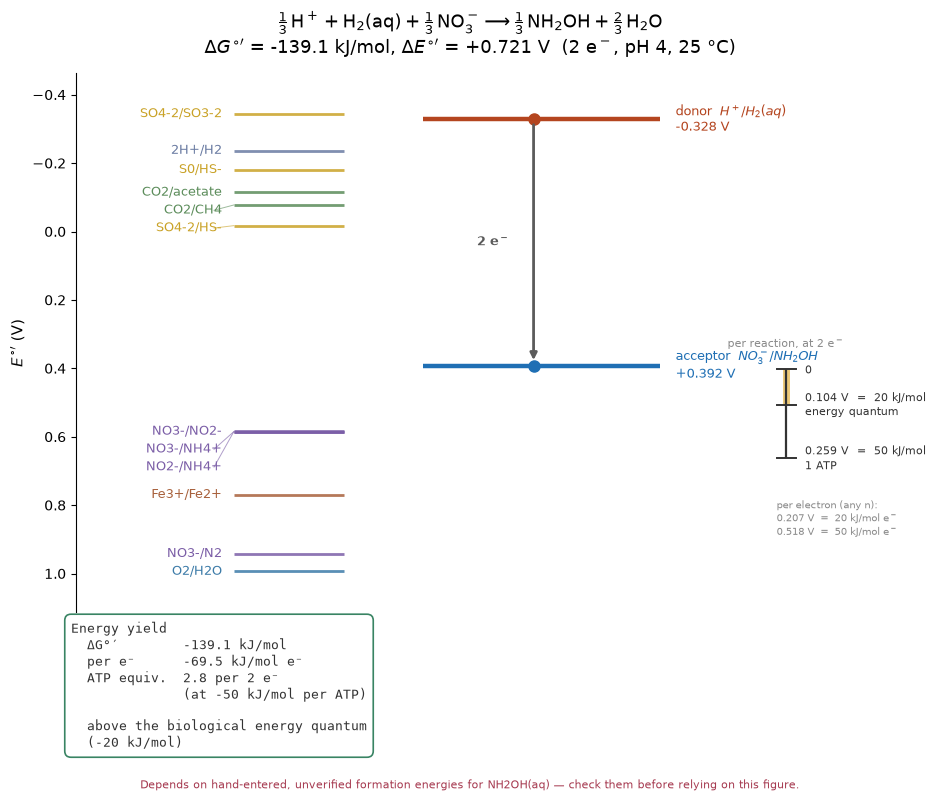

In [11]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    plot_redox_tower(per_pair)
plt.show()

Compare the two energy panels: ΔG°′ scales with the reaction while ΔG per
electron and ΔE°′ do not. That is the whole reason the library normalises
figures to an electron pair by default.

In [12]:
for label, built in (("per nitrate", per_nitrate), ("per electron pair", per_pair)):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        print(
            f"{label:18s} n={built.n_electrons!s:>4s}  "
            f"dG0' = {built.delta_G_standard_prime.magnitude:+8.1f} kJ/mol   "
            f"per e- = {built.delta_G_per_electron.magnitude:+7.2f}   "
            f"dE0' = {built.delta_E_standard_prime.to('V').magnitude:+.3f} V"
        )

per nitrate        n=   6  dG0' =   -417.3 kJ/mol   per e- =  -69.55   dE0' = +0.721 V
per electron pair  n=   2  dG0' =   -139.1 kJ/mol   per e- =  -69.55   dE0' = +0.721 V


## 6. Free energy against pH

pH is the first entry in the dropdown; the other axes are there too. The
temperature axis is deliberately left out: hydroxylamine's supplemental value
is tabulated at 25 °C only and refuses to extrapolate, so a temperature sweep
would be all gaps.

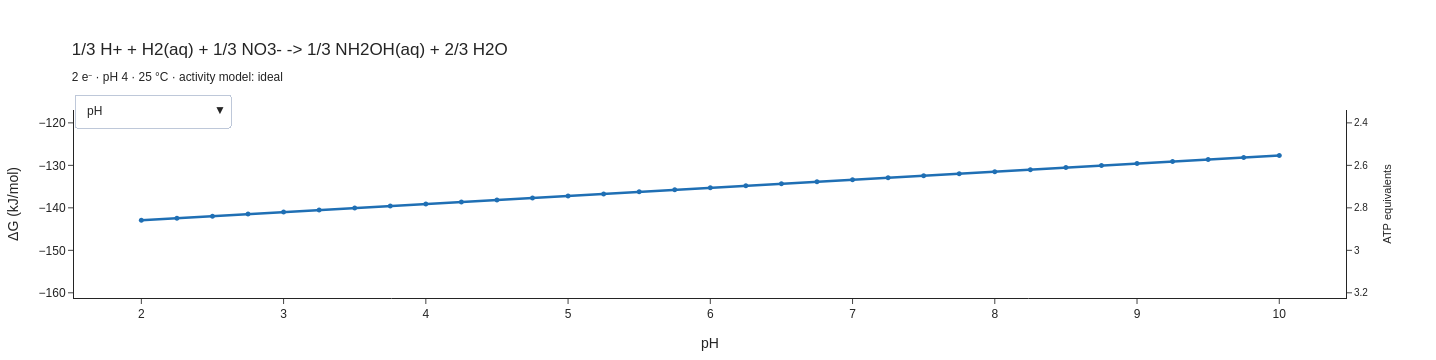

In [13]:
from microbial_thermo.sweep import concentration_axis, partial_pressure_axis, ph_axis

axes = [
    ph_axis(low=2.0, high=10.0, n=33),
    concentration_axis("NO3-"),
    concentration_axis("NH2OH(aq)"),
    partial_pressure_axis("H2(aq)"),
]

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    figure = plot_energy_explorer(per_pair, axes=axes)

figure.show()

## 7. Show the work

Every number above, traced back to where it came from.

In [14]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    work = per_pair.show_work()
work

## Derivation: 1/3 H+ + H2(aq) + 1/3 NO3- -> 1/3 NH2OH(aq) + 2/3 H2O

**Step 1. Identify the redox couples**

- Electron donor: H+/H2(aq) — H goes from +1 on the oxidized side to 0 on the reduced side
- Electron acceptor: NO3-/NH2OH(aq) — N goes from +5 on the oxidized side to -1 on the reduced side
- The donor is written in the oxidative direction and the acceptor in the reductive direction, normalised to 2 electrons.

**Step 2. Balance each half reaction**

Balance the redox-active element first, then oxygen with $\mathrm{H_2O}$, hydrogen with $\mathrm{H^+}$, and finally charge with electrons.

Oxidation (electron donor):
$$ \mathrm{H_2(aq)} \longrightarrow 2\,\mathrm{H^+} + 2\,\mathrm{e^-} $$
Reduction (electron acceptor):
$$ \tfrac{1}{3}\,\mathrm{NO_3^-} + \tfrac{7}{3}\,\mathrm{H^+} + 2\,\mathrm{e^-} \longrightarrow \tfrac{1}{3}\,\mathrm{NH_2OH} + \tfrac{2}{3}\,\mathrm{H_2O} $$

**Step 3. Add the half reactions so the electrons cancel**

$$ \tfrac{1}{3}\,\mathrm{H^+} + \mathrm{H_2(aq)} + \tfrac{1}{3}\,\mathrm{NO_3^-} \longrightarrow \tfrac{1}{3}\,\mathrm{NH_2OH} + \tfrac{2}{3}\,\mathrm{H_2O} $$
Both halves are scaled to 2 electrons, so the electrons cancel exactly and the sum conserves atoms and charge.

**Step 4. Look up standard formation energies**

At 25 °C from pygcc 1.5.3 (speq21.dat (pyGCC default)):

| species | ν | ΔG°f (kJ/mol) | ν·ΔG°f |
|---|---:|---:|---:|
| H+ | -1/3 | 0.00 | -0.00 |
| H2(aq) | -1 | 17.72 | -17.72 |
| H2O | +2/3 | -237.18 | -158.12 |
| NH2OH(aq) | +1/3 | -23.50 | -7.83 |
| NO3- | -1/3 | -110.91 | +36.97 |

By convention $\Delta G^\circ_f(\mathrm{H^+}) = 0$ and $\Delta G^\circ_f(e^-) = 0$, which places every potential on the standard hydrogen electrode.
$$ \Delta G^\circ = \sum_i \nu_i \Delta G^\circ_{f,i} = -146.71\ \mathrm{kJ\,mol^{-1}} $$

**Step 5. Build the reaction quotient**

Activity model: `ideal`, pH 4.

| species | ν | activity | ν·ln a |
|---|---:|---:|---:|
| H+ | -1/3 | 0.0001 | +3.0701 |
| H2(aq) | -1 | 1 | -0.0000 |
| H2O | +2/3 | 1 | +0.0000 |
| NH2OH(aq) | +1/3 | 1 | +0.0000 |
| NO3- | -1/3 | 1 | -0.0000 |

$$ \ln Q = +3.0701 $$
$$ RT = 8.3145\ \mathrm{J\,mol^{-1}K^{-1}} \times 298.15\ \mathrm{K} = 2.47896\ \mathrm{kJ\,mol^{-1}} $$
$$ RT\ln Q = 2.47896 \times +3.0701 = +7.61\ \mathrm{kJ\,mol^{-1}} $$

**Step 6. Combine into the free energy**

$$ \Delta G = \Delta G^\circ + RT\ln Q = -146.71 +7.61 = -139.10\ \mathrm{kJ\,mol^{-1}} $$
At unit activities but pH 4, $\Delta G^{\circ\prime} = -139.10$ kJ/mol.
Per mole of electrons: $-69.55$ kJ/mol e⁻.

**Step 7. Convert to potentials**

$$ E = \frac{-\Delta G_\mathrm{half}}{nF} $$
- donor H+/H2(aq): $E^\circ = -0.092$ V, $E^{\circ\prime} = -0.328$ V
- acceptor NO3-/NH2OH(aq): $E^\circ = +0.668$ V, $E^{\circ\prime} = +0.392$ V
$$ \Delta E^{\circ\prime} = E_\mathrm{acceptor} - E_\mathrm{donor} = +0.721\ \mathrm{V} $$

**Step 8. Cross-check by an independent path**

The free energy is computed twice: once by summing formation energies over the whole reaction, and once from the two half-reaction potentials. Agreement confirms the half reactions really do sum to the combined reaction, with the right electron count and no sign slip.

Building the potentials takes three steps each, so they are worked out in full below. Both halves are treated as **reductions**, which is the convention that makes potentials comparable — the donor is shown oxidatively elsewhere, but not here.

**a. Correct each potential from the standard state.**
$$ E = E^\circ - \frac{RT}{nF}\sum_i \nu_i \ln a_i $$

*Donor: H+/H2(aq)*, as a reduction, n = 2:

| species | ν | activity | ν·ln a | ΔE term (V) |
|---|---:|---:|---:|---:|
| H+ | -2 | 0.0001 | +18.4207 | -0.2366 |
| H2(aq) | +1 | 1 | +0.0000 | +0.0000 |

- $E^\circ$ = -0.0918 V — every activity 1, so every term above is zero.
- $E^{\circ\prime}$ = -0.0918 -0.2366 = -0.3285 V — the proton term alone, at pH 4.
- $E$ = -0.0918 -0.2366 = -0.3285 V — every term, at the stated conditions.

*Acceptor: NO3-/NH2OH(aq)*, as a reduction, n = 2:

| species | ν | activity | ν·ln a | ΔE term (V) |
|---|---:|---:|---:|---:|
| H+ | -7/3 | 0.0001 | +21.4908 | -0.2761 |
| H2O | +2/3 | 1 | +0.0000 | +0.0000 |
| NH2OH(aq) | +1/3 | 1 | +0.0000 | +0.0000 |
| NO3- | -1/3 | 1 | +0.0000 | +0.0000 |

- $E^\circ$ = +0.6684 V — every activity 1, so every term above is zero.
- $E^{\circ\prime}$ = +0.6684 -0.2761 = +0.3923 V — the proton term alone, at pH 4.
- $E$ = +0.6684 -0.2761 = +0.3923 V — every term, at the stated conditions.

**b. Subtract.** Electrons fall from the donor to the acceptor:
$$ \Delta E = E_\mathrm{acceptor} - E_\mathrm{donor} = +0.3923 - (-0.3285) = +0.7208\ \mathrm{V} $$

**c. Convert, and compare against the formation-energy sum.**
$$ -nF\Delta E = -2 \times 96.485 \times +0.7208 = -139.10\ \mathrm{kJ\,mol^{-1}} $$

| route | ΔG (kJ/mol) |
|---|---:|
| sum of formation energies (step 6) | -139.0966 |
| −nFΔE, from the potentials above | -139.0966 |
| difference | +2.84e-14 |

The two agree, so the half reactions really do sum to the combined reaction. ✓


# Ammonia oxidation by manganese oxide, pH 10

pH 10 is chosen deliberately: ammonia's p*K*a is near 9.2, so above it the
neutral NH₃ is the dominant form rather than ammonium. Worth checking before
writing the reaction with one form or the other.

In [15]:
mt.speciation_table("ammonia", 10.0)

,species,fraction,percent,pKa to next
0,NH4+,0.148341,14.83409,9.24
1,NH3(aq),0.851659,85.16591,


In [31]:
alkaline = mt.Conditions(temperature_c=25.0, pH=10.0)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    manganese = mt.Reaction.from_equation(
        "NH3 + MnO2 -> N2 + Mn+2", conditions=alkaline, n_electrons=2
    )

print(manganese.summary())

Reaction:  2/3 NH3(aq) + 2 H+ + Pyrolusite -> 1/3 N2(aq) + Mn++ + 2 H2O
  donor     N2(aq)/NH3(aq)  (oxidative)  E0' = -0.468 V
  acceptor  Pyrolusite/Mn++  (reductive)  E0' = +0.045 V
  n electrons        2
  dE0'               +0.513 V
  dG0'               -99.0 kJ/mol
  dG (conditions)    -99.0 kJ/mol
  dG per electron    -49.5 kJ/mol e-


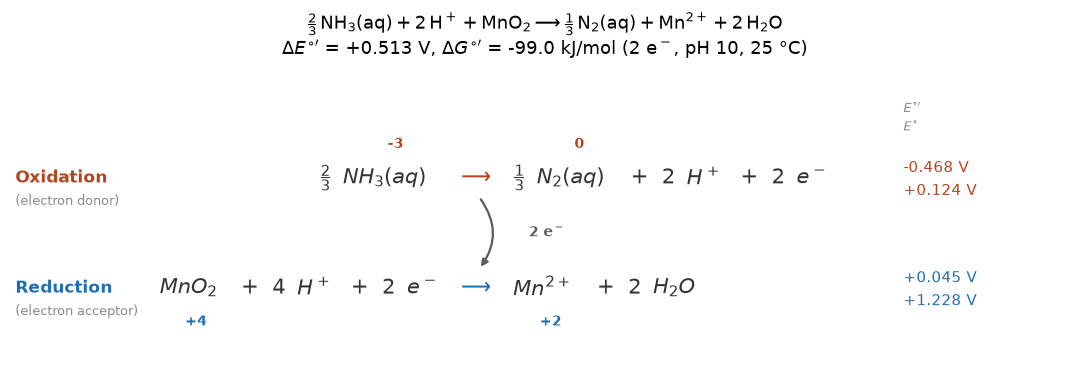

In [32]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    plot_half_reactions(manganese)
plt.show()

Manganese(IV) is a strong enough oxidant to take ammonia all the way to N₂,
and strongly exergonic at that. Note this is written with pyrolusite, which
has a full temperature grid; several other manganese oxides in the database
are tabulated at 25 °C only and will refuse other temperatures.

The tower, at an electron pair so it can be set against the other two
questions directly. Note the acceptor rung sits where pH 10 puts it, not
where a pH 7 table would.

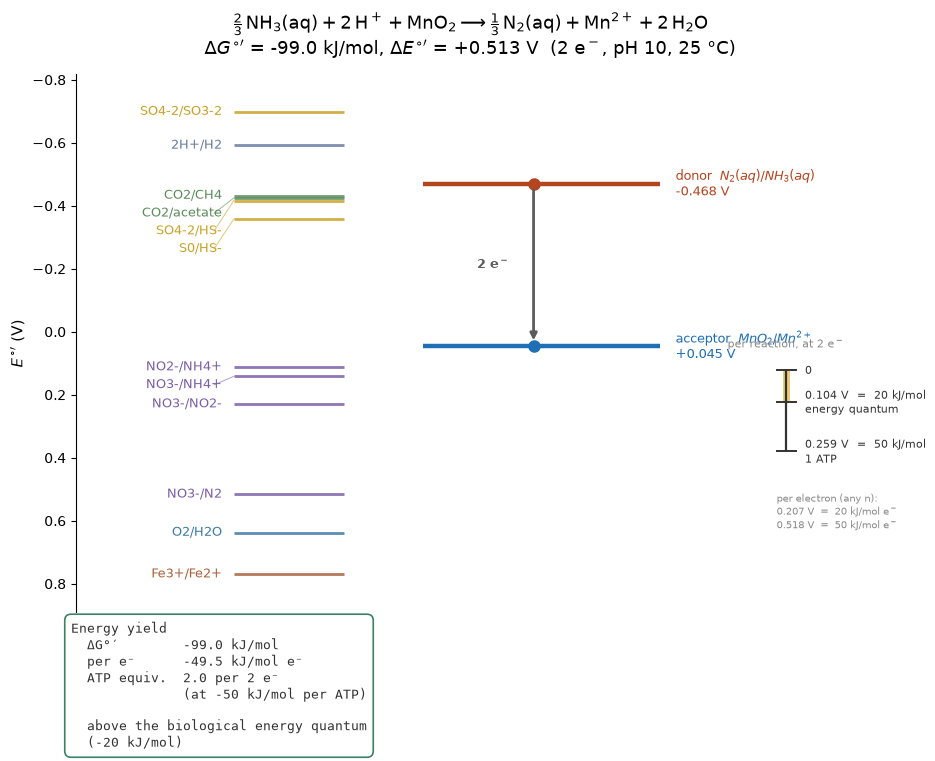

In [33]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    plot_redox_tower(manganese)
plt.show()

Free energy against pH. Written for an electron pair this reaction **consumes**
two protons, one per electron, so raising the pH makes it *less* favourable:
−156 kJ/mol at pH 5, −88 at pH 11. The slope is
$\nu_{H^+} RT\ln 10$ = 11.4 kJ/mol per pH unit.

Temperature is in the dropdown here, unlike the first question: pyrolusite has
a full log K grid, where hydroxylamine did not.

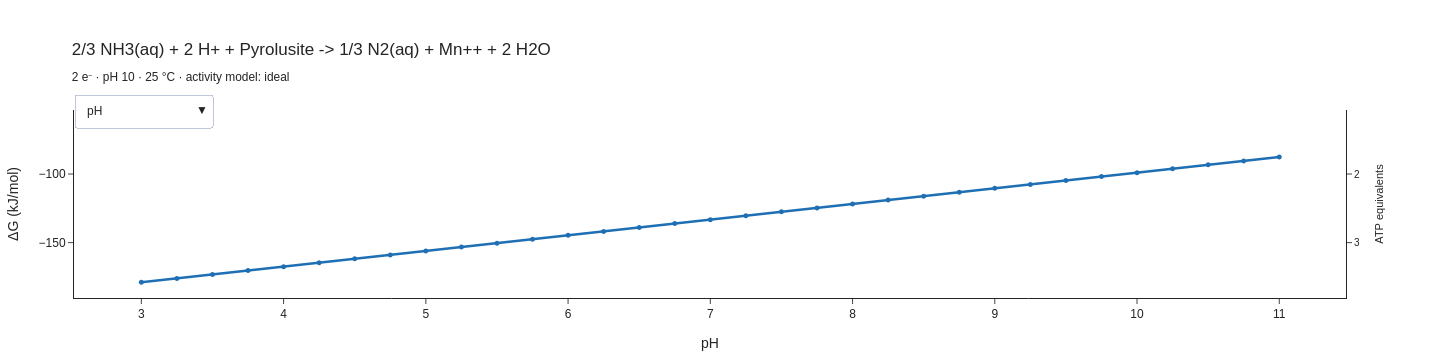

In [34]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    manganese_explorer = plot_energy_explorer(manganese.renormalized(2))

manganese_explorer.show()

## Show the work

Every number above, traced back to where it came from.

In [35]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    work = manganese.show_work()
work

## Derivation: 2/3 NH3(aq) + 2 H+ + Pyrolusite -> 1/3 N2(aq) + Mn++ + 2 H2O

**Step 1. Identify the redox couples**

- Electron donor: N2(aq)/NH3(aq) — N goes from 0 on the oxidized side to -3 on the reduced side
- Electron acceptor: Pyrolusite/Mn++ — Mn goes from +4 on the oxidized side to +2 on the reduced side
- The donor is written in the oxidative direction and the acceptor in the reductive direction, normalised to 2 electrons.

**Step 2. Balance each half reaction**

Balance the redox-active element first, then oxygen with $\mathrm{H_2O}$, hydrogen with $\mathrm{H^+}$, and finally charge with electrons.

Oxidation (electron donor):
$$ \tfrac{2}{3}\,\mathrm{NH_3(aq)} \longrightarrow \tfrac{1}{3}\,\mathrm{N_2(aq)} + 2\,\mathrm{H^+} + 2\,\mathrm{e^-} $$
Reduction (electron acceptor):
$$ \mathrm{MnO_2} + 4\,\mathrm{H^+} + 2\,\mathrm{e^-} \longrightarrow \mathrm{Mn^{2+}} + 2\,\mathrm{H_2O} $$

**Step 3. Add the half reactions so the electrons cancel**

$$ \tfrac{2}{3}\,\mathrm{NH_3(aq)} + 2\,\mathrm{H^+} + \mathrm{MnO_2} \longrightarrow \tfrac{1}{3}\,\mathrm{N_2(aq)} + \mathrm{Mn^{2+}} + 2\,\mathrm{H_2O} $$
Both halves are scaled to 2 electrons, so the electrons cancel exactly and the sum conserves atoms and charge.

**Step 4. Look up standard formation energies**

At 25 °C from pygcc 1.5.3 (speq21.dat (pyGCC default)):

| species | ν | ΔG°f (kJ/mol) | ν·ΔG°f |
|---|---:|---:|---:|
| H+ | -2 | 0.00 | -0.00 |
| H2O | +2 | -237.18 | -474.36 |
| Mn++ | +1 | -230.54 | -230.54 |
| N2(aq) | +1/3 | 18.19 | +6.06 |
| NH3(aq) | -2/3 | -26.71 | +17.80 |
| Pyrolusite | -1 | -467.86 | +467.86 |

By convention $\Delta G^\circ_f(\mathrm{H^+}) = 0$ and $\Delta G^\circ_f(e^-) = 0$, which places every potential on the standard hydrogen electrode.
$$ \Delta G^\circ = \sum_i \nu_i \Delta G^\circ_{f,i} = -213.17\ \mathrm{kJ\,mol^{-1}} $$

**Step 5. Build the reaction quotient**

Activity model: `ideal`, pH 10.

| species | ν | activity | ν·ln a |
|---|---:|---:|---:|
| H+ | -2 | 1e-10 | +46.0517 |
| H2O | +2 | 1 | +0.0000 |
| Mn++ | +1 | 1 | +0.0000 |
| N2(aq) | +1/3 | 1 | +0.0000 |
| NH3(aq) | -2/3 | 1 | -0.0000 |
| Pyrolusite | -1 | 1 | -0.0000 |

$$ \ln Q = +46.0517 $$
$$ RT = 8.3145\ \mathrm{J\,mol^{-1}K^{-1}} \times 298.15\ \mathrm{K} = 2.47896\ \mathrm{kJ\,mol^{-1}} $$
$$ RT\ln Q = 2.47896 \times +46.0517 = +114.16\ \mathrm{kJ\,mol^{-1}} $$

**Step 6. Combine into the free energy**

$$ \Delta G = \Delta G^\circ + RT\ln Q = -213.17 +114.16 = -99.01\ \mathrm{kJ\,mol^{-1}} $$
At unit activities but pH 10, $\Delta G^{\circ\prime} = -99.01$ kJ/mol.
Per mole of electrons: $-49.51$ kJ/mol e⁻.

**Step 7. Convert to potentials**

$$ E = \frac{-\Delta G_\mathrm{half}}{nF} $$
- donor N2(aq)/NH3(aq): $E^\circ = +0.124$ V, $E^{\circ\prime} = -0.468$ V
- acceptor Pyrolusite/Mn++: $E^\circ = +1.228$ V, $E^{\circ\prime} = +0.045$ V
$$ \Delta E^{\circ\prime} = E_\mathrm{acceptor} - E_\mathrm{donor} = +0.513\ \mathrm{V} $$

**Step 8. Cross-check by an independent path**

The free energy is computed twice: once by summing formation energies over the whole reaction, and once from the two half-reaction potentials. Agreement confirms the half reactions really do sum to the combined reaction, with the right electron count and no sign slip.

Building the potentials takes three steps each, so they are worked out in full below. Both halves are treated as **reductions**, which is the convention that makes potentials comparable — the donor is shown oxidatively elsewhere, but not here.

**a. Correct each potential from the standard state.**
$$ E = E^\circ - \frac{RT}{nF}\sum_i \nu_i \ln a_i $$

*Donor: N2(aq)/NH3(aq)*, as a reduction, n = 2:

| species | ν | activity | ν·ln a | ΔE term (V) |
|---|---:|---:|---:|---:|
| H+ | -2 | 1e-10 | +46.0517 | -0.5916 |
| N2(aq) | -1/3 | 1 | +0.0000 | +0.0000 |
| NH3(aq) | +2/3 | 1 | +0.0000 | +0.0000 |

- $E^\circ$ = +0.1237 V — every activity 1, so every term above is zero.
- $E^{\circ\prime}$ = +0.1237 -0.5916 = -0.4679 V — the proton term alone, at pH 10.
- $E$ = +0.1237 -0.5916 = -0.4679 V — every term, at the stated conditions.

*Acceptor: Pyrolusite/Mn++*, as a reduction, n = 2:

| species | ν | activity | ν·ln a | ΔE term (V) |
|---|---:|---:|---:|---:|
| H+ | -4 | 1e-10 | +92.1034 | -1.1832 |
| H2O | +2 | 1 | +0.0000 | +0.0000 |
| Mn++ | +1 | 1 | +0.0000 | +0.0000 |
| Pyrolusite | -1 | 1 | +0.0000 | +0.0000 |

- $E^\circ$ = +1.2284 V — every activity 1, so every term above is zero.
- $E^{\circ\prime}$ = +1.2284 -1.1832 = +0.0452 V — the proton term alone, at pH 10.
- $E$ = +1.2284 -1.1832 = +0.0452 V — every term, at the stated conditions.

**b. Subtract.** Electrons fall from the donor to the acceptor:
$$ \Delta E = E_\mathrm{acceptor} - E_\mathrm{donor} = +0.0452 - (-0.4679) = +0.5131\ \mathrm{V} $$

**c. Convert, and compare against the formation-energy sum.**
$$ -nF\Delta E = -2 \times 96.485 \times +0.5131 = -99.01\ \mathrm{kJ\,mol^{-1}} $$

| route | ΔG (kJ/mol) |
|---|---:|
| sum of formation energies (step 6) | -99.0106 |
| −nFΔE, from the potentials above | -99.0106 |
| difference | -1.42e-14 |

The two agree, so the half reactions really do sum to the combined reaction. ✓


# Ammonium oxidation to N₂ under oxygen, pH 7

In [21]:
neutral = mt.Conditions(temperature_c=25.0, pH=7.0)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    aerobic = mt.Reaction.from_equation(
        "NH4+ + O2 -> N2", conditions=neutral, normalize_to="integer"
    )

print(aerobic.summary())

Reaction:  4 NH4+ + 3 O2(aq) -> 2 N2(aq) + 4 H+ + 6 H2O
  donor     N2(aq)/NH4+  (oxidative)  E0' = -0.246 V
  acceptor  O2(aq)/H2O  (reductive)  E0' = +0.858 V
  n electrons        12
  dE0'               +1.104 V
  dG0'               -1278.3 kJ/mol
  dG (conditions)    -1278.3 kJ/mol
  dG per electron    -106.5 kJ/mol e-


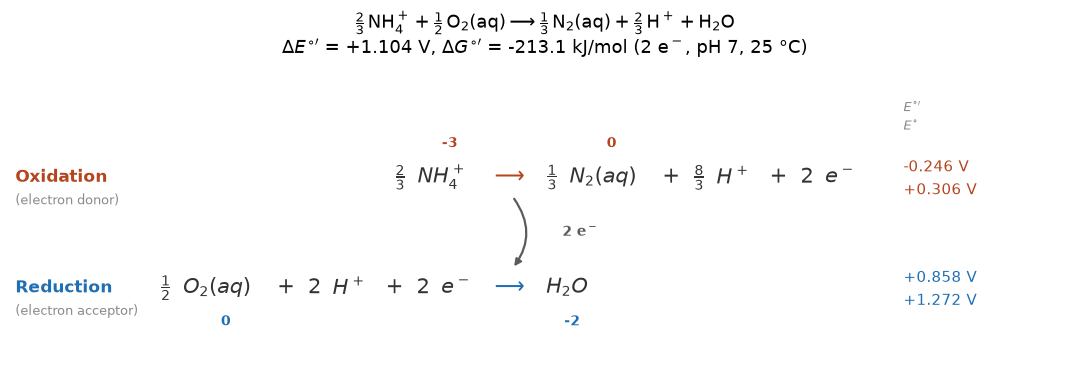

In [22]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    plot_half_reactions(aerobic)
plt.show()

The tower again at an electron pair. The gap here is the widest of the three,
which is what the free energy per electron already said.

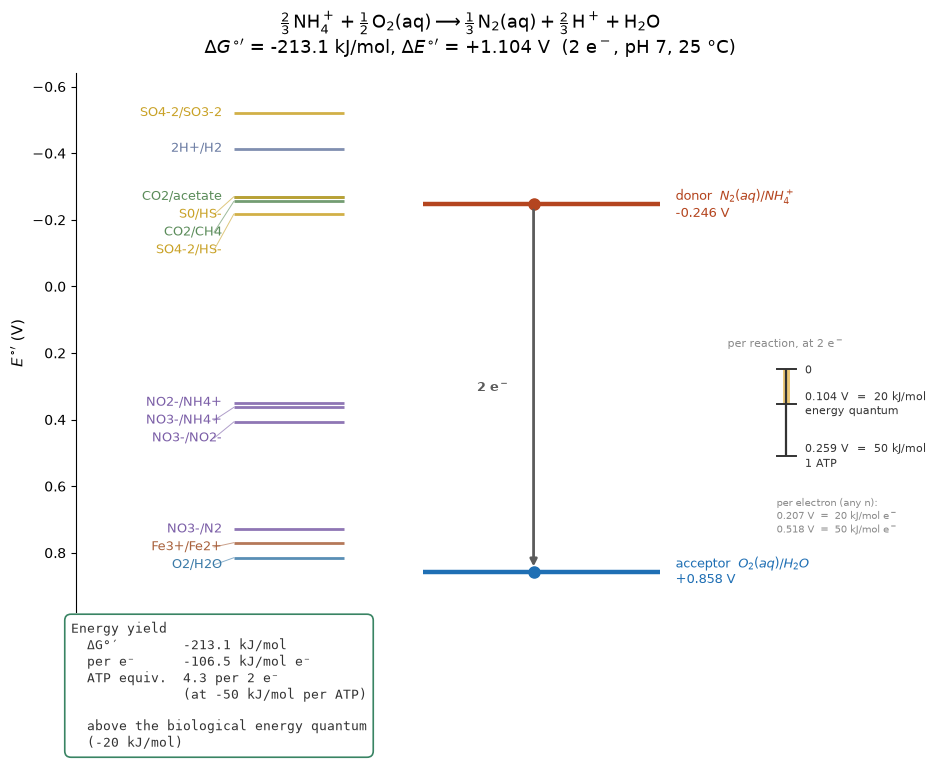

In [23]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    plot_redox_tower(aerobic)
plt.show()

Free energy against pH — and compare it with the manganese case, because the
two go in *opposite directions*. This reaction **releases** two thirds of a
proton per electron pair, so raising the pH makes it *more* favourable:
−205 kJ/mol at pH 5, −228 at pH 11.

The slope is 3.8 kJ/mol per pH unit against manganese's 11.4 — a factor of
three, which is exactly the ratio of their proton coefficients (1 per electron
against 1/3). Nothing about pH sensitivity is arbitrary: it is the proton
stoichiometry, read straight off the balanced half reactions.

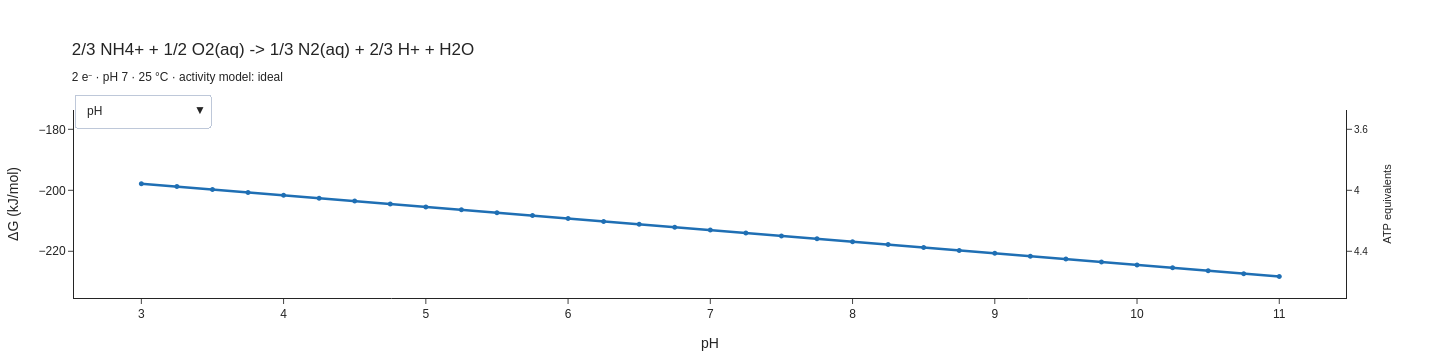

In [24]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    aerobic_explorer = plot_energy_explorer(aerobic.renormalized(2))

aerobic_explorer.show()

## Show the work

Every number above, traced back to where it came from.

In [29]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    work = aerobic.show_work()
work

## Derivation: 4 NH4+ + 3 O2(aq) -> 2 N2(aq) + 4 H+ + 6 H2O

**Step 1. Identify the redox couples**

- Electron donor: N2(aq)/NH4+ — N goes from 0 on the oxidized side to -3 on the reduced side
- Electron acceptor: O2(aq)/H2O — O goes from 0 on the oxidized side to -2 on the reduced side
- The donor is written in the oxidative direction and the acceptor in the reductive direction, normalised to 12 electrons.

**Step 2. Balance each half reaction**

Balance the redox-active element first, then oxygen with $\mathrm{H_2O}$, hydrogen with $\mathrm{H^+}$, and finally charge with electrons.

Oxidation (electron donor):
$$ 4\,\mathrm{NH_4^+} \longrightarrow 2\,\mathrm{N_2(aq)} + 16\,\mathrm{H^+} + 12\,\mathrm{e^-} $$
Reduction (electron acceptor):
$$ 3\,\mathrm{O_2(aq)} + 12\,\mathrm{H^+} + 12\,\mathrm{e^-} \longrightarrow 6\,\mathrm{H_2O} $$

**Step 3. Add the half reactions so the electrons cancel**

$$ 4\,\mathrm{NH_4^+} + 3\,\mathrm{O_2(aq)} \longrightarrow 2\,\mathrm{N_2(aq)} + 4\,\mathrm{H^+} + 6\,\mathrm{H_2O} $$
Both halves are scaled to 12 electrons, so the electrons cancel exactly and the sum conserves atoms and charge.

**Step 4. Look up standard formation energies**

At 25 °C from pygcc 1.5.3 (speq21.dat (pyGCC default)):

| species | ν | ΔG°f (kJ/mol) | ν·ΔG°f |
|---|---:|---:|---:|
| H+ | +4 | 0.00 | +0.00 |
| H2O | +6 | -237.18 | -1423.07 |
| N2(aq) | +2 | 18.19 | +36.38 |
| NH4+ | -4 | -79.45 | +317.82 |
| O2(aq) | -3 | 16.54 | -49.63 |

By convention $\Delta G^\circ_f(\mathrm{H^+}) = 0$ and $\Delta G^\circ_f(e^-) = 0$, which places every potential on the standard hydrogen electrode.
$$ \Delta G^\circ = \sum_i \nu_i \Delta G^\circ_{f,i} = -1118.51\ \mathrm{kJ\,mol^{-1}} $$

**Step 5. Build the reaction quotient**

Activity model: `ideal`, pH 7.

| species | ν | activity | ν·ln a |
|---|---:|---:|---:|
| H+ | +4 | 1e-07 | -64.4724 |
| H2O | +6 | 1 | +0.0000 |
| N2(aq) | +2 | 1 | +0.0000 |
| NH4+ | -4 | 1 | -0.0000 |
| O2(aq) | -3 | 1 | -0.0000 |

$$ \ln Q = -64.4724 $$
$$ RT = 8.3145\ \mathrm{J\,mol^{-1}K^{-1}} \times 298.15\ \mathrm{K} = 2.47896\ \mathrm{kJ\,mol^{-1}} $$
$$ RT\ln Q = 2.47896 \times -64.4724 = -159.82\ \mathrm{kJ\,mol^{-1}} $$

**Step 6. Combine into the free energy**

$$ \Delta G = \Delta G^\circ + RT\ln Q = -1118.51 -159.82 = -1278.33\ \mathrm{kJ\,mol^{-1}} $$
At unit activities but pH 7, $\Delta G^{\circ\prime} = -1278.33$ kJ/mol.
Per mole of electrons: $-106.53$ kJ/mol e⁻.

**Step 7. Convert to potentials**

$$ E = \frac{-\Delta G_\mathrm{half}}{nF} $$
- donor N2(aq)/NH4+: $E^\circ = +0.306$ V, $E^{\circ\prime} = -0.246$ V
- acceptor O2(aq)/H2O: $E^\circ = +1.272$ V, $E^{\circ\prime} = +0.858$ V
$$ \Delta E^{\circ\prime} = E_\mathrm{acceptor} - E_\mathrm{donor} = +1.104\ \mathrm{V} $$

**Step 8. Cross-check by an independent path**

The free energy is computed twice: once by summing formation energies over the whole reaction, and once from the two half-reaction potentials. Agreement confirms the half reactions really do sum to the combined reaction, with the right electron count and no sign slip.

Building the potentials takes three steps each, so they are worked out in full below. Both halves are treated as **reductions**, which is the convention that makes potentials comparable — the donor is shown oxidatively elsewhere, but not here.

**a. Correct each potential from the standard state.**
$$ E = E^\circ - \frac{RT}{nF}\sum_i \nu_i \ln a_i $$

*Donor: N2(aq)/NH4+*, as a reduction, n = 12:

| species | ν | activity | ν·ln a | ΔE term (V) |
|---|---:|---:|---:|---:|
| H+ | -16 | 1e-07 | +257.8895 | -0.5522 |
| N2(aq) | -2 | 1 | +0.0000 | +0.0000 |
| NH4+ | +4 | 1 | +0.0000 | +0.0000 |

- $E^\circ$ = +0.3059 V — every activity 1, so every term above is zero.
- $E^{\circ\prime}$ = +0.3059 -0.5522 = -0.2462 V — the proton term alone, at pH 7.
- $E$ = +0.3059 -0.5522 = -0.2462 V — every term, at the stated conditions.

*Acceptor: O2(aq)/H2O*, as a reduction, n = 12:

| species | ν | activity | ν·ln a | ΔE term (V) |
|---|---:|---:|---:|---:|
| H+ | -12 | 1e-07 | +193.4171 | -0.4141 |
| H2O | +6 | 1 | +0.0000 | +0.0000 |
| O2(aq) | -3 | 1 | +0.0000 | +0.0000 |

- $E^\circ$ = +1.2720 V — every activity 1, so every term above is zero.
- $E^{\circ\prime}$ = +1.2720 -0.4141 = +0.8578 V — the proton term alone, at pH 7.
- $E$ = +1.2720 -0.4141 = +0.8578 V — every term, at the stated conditions.

**b. Subtract.** Electrons fall from the donor to the acceptor:
$$ \Delta E = E_\mathrm{acceptor} - E_\mathrm{donor} = +0.8578 - (-0.2462) = +1.1041\ \mathrm{V} $$

**c. Convert, and compare against the formation-energy sum.**
$$ -nF\Delta E = -12 \times 96.485 \times +1.1041 = -1278.33\ \mathrm{kJ\,mol^{-1}} $$

| route | ΔG (kJ/mol) |
|---|---:|
| sum of formation energies (step 6) | -1278.3330 |
| −nFΔE, from the potentials above | -1278.3330 |
| difference | +2.27e-13 |

The two agree, so the half reactions really do sum to the combined reaction. ✓


# The three side by side

Per electron, so they are comparable despite very different electron counts.

In [26]:
rows = [
    ("NO3- + H2 -> NH2OH", per_pair, conditions),
    ("NH3 + MnO2 -> N2 + Mn+2", manganese, alkaline),
    ("NH4+ + O2 -> N2", aerobic, neutral),
]
print(f"{'equation':28s} {'pH':>5s} {'n':>3s} {'dG0prime':>11s} {'per e-':>9s} {'dE0prime':>9s}")
for label, built, where in rows:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        print(
            f"{label:28s} {where.pH:5.1f} {built.n_electrons!s:>3s} "
            f"{built.delta_G_standard_prime.magnitude:11.1f} "
            f"{built.delta_G_per_electron.magnitude:9.2f} "
            f"{built.delta_E_standard_prime.to('V').magnitude:+9.3f}"
        )

equation                        pH   n    dG0prime    per e-  dE0prime
NO3- + H2 -> NH2OH             4.0   2      -139.1    -69.55    +0.721
NH3 + MnO2 -> N2 + Mn+2       10.0   6      -297.0    -49.51    +0.513
NH4+ + O2 -> N2                7.0  12     -1278.3   -106.53    +1.104


A caution about reading that table. The three rows are **not** a fair
comparison of acceptor strength: each uses a different electron donor, and
each sits at a different pH. Oxygen looks best partly because it is, and
partly because its donor is ammonium rather than ammonia.

To compare acceptors properly, hold the donor and the pH fixed and look at the
acceptor half reactions alone — which is exactly what the redox tower does:

In [27]:
from microbial_thermo.reaction import Couple, HalfReactionResult

same_conditions = mt.Conditions(temperature_c=25.0, pH=7.0)
for reduced, oxidized in [
    ("H2O", "O2(aq)"),
    ("Mn+2", "pyrolusite"),
    ("NH2OH(aq)", "NO3-"),
]:
    pair = Couple.make(reduced, oxidized)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = HalfReactionResult(
            couple=pair, half=pair.half_reaction(),
            conditions=same_conditions, backend=mt.get_backend(),
        )
        value = result.E_standard_prime.to("V").magnitude
    print(f"{str(pair):26s} E0' = {value:+.3f} V  (pH 7)")

O2(aq)/H2O                 E0' = +0.858 V  (pH 7)
Pyrolusite/Mn++            E0' = +0.400 V  (pH 7)
NO3-/NH2OH(aq)             E0' = +0.185 V  (pH 7)


On a common footing the order is oxygen, then manganese(IV), then nitrate to
hydroxylamine. Pyrolusite looked weak in the table above only because pH 10
penalises a couple that consumes four protons — the same reaction is far more
favourable at pH 7.

Only the nitrate row depends on the unverified hydroxylamine value; the other
two rest entirely on pyGCC data.